# Stage 1: Purchase Propensity Model

Binary classifier predicting **whether a customer will purchase in the 180-day holdout window**.

- **Target:** `purchased_in_holdout = (actual_holdout_transactions > 0)` — ~12.3% positive
- **Model:** XGBoost with `scale_pos_weight` for class imbalance + isotonic calibration
- **Primary metric:** PR-AUC (baseline = 0.123)

**Outputs:**
- `models/purchase_propensity_model.pkl`
- `data/processed/stage1_scored.csv`

---

> **TODO:**

- explain why I chose XGBoost model instead of other ML (e.g., random forest, lightGBM, etc.)
- explain why I chose primary metric as PR-AUC.
- elaborate how `scale_pos_weight` helps class imbalance + **isotonic calibration**
- explain logic for determining params in XGBoost classifier
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, 
    roc_auc_score,
    precision_recall_curve
)
import xgboost as xgb

# Settings
sns.set_style('darkgrid')

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv("../data/raw/clv_data.csv")

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

Loaded 52,507 customers
Positive class (purchased in holdout): 6,451 (12.3%)
Negative class (no holdout purchase):  46,056 (87.7%)


## 2. Exploratory Data Analysis (EDA)

This dataset contains customer behavioral, demographic, and transaction data used to predict whether a customer will make a purchase in a future holdout period.

Key dataset characteristics:
- 52,507 customers
- Behavioral engagement features (sessions, events)
- Purchase history features (frequency, recency, monetary value)
- Demographics and traffic source

In [3]:
print(f"Shape: {df.shape}")
df.head(10)

Shape: (52507, 25)


,user_id,frequency,recency,T,monetary_value,total_orders,total_spend,avg_order_value,days_since_last_order,actual_holdout_transactions,...,country,total_sessions,total_events,days_since_last_visit,avg_events_per_session,distinct_event_types,cart_events,product_view_events,purchase_events,purchased_in_holdout
0,34756,1,993,1064,411.750000,2,465.490002,232.745001,71,0,...,China,7,82,70,11.714286,4,25,25,7,0
1,9513,2,743,1062,94.719997,3,297.019993,99.006664,319,0,...,China,6,49,319,8.166667,5,14,14,6,0
2,74483,2,436,685,150.335000,3,321.920000,107.306667,249,1,...,South Korea,7,71,249,10.142857,5,21,21,7,1
3,69957,1,138,1701,196.759998,2,239.569998,119.784999,1563,0,...,France,7,82,1559,11.714286,4,25,25,7,0
4,67994,2,362,1576,156.990001,3,435.670000,145.223333,1214,0,...,China,8,80,1214,10.000000,4,24,24,8,0
5,90317,3,591,656,34.796667,4,312.970002,78.242501,65,0,...,United Kingdom,9,92,65,10.222222,5,27,27,9,0
6,11507,2,831,1159,111.785002,3,303.020000,101.006667,328,1,...,Germany,5,40,328,8.000000,5,11,11,5,1
7,40164,1,1140,1237,71.980000,2,241.639999,120.820000,97,0,...,China,6,66,95,11.000000,4,20,20,6,0
8,91120,2,732,1092,36.995000,3,263.029998,87.676666,360,0,...,United States,5,40,360,8.000000,5,11,11,5,0
9,23479,1,499,682,186.730004,2,277.230004,138.615002,183,0,...,United States,6,66,180,11.000000,4,20,20,6,0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,52507.0,49948.269907,28893.416003,1.00,24831.500000,50046.000000,74923.000000,99999.000000
frequency,52507.0,0.422896,0.726733,0.00,0.000000,0.000000,1.000000,3.000000
recency,52507.0,165.316301,346.131637,0.00,0.000000,0.000000,132.000000,2164.000000
T,52507.0,723.394290,532.090185,8.00,275.000000,615.000000,1092.000000,2276.000000
monetary_value,52507.0,86.550571,91.819948,0.02,30.000000,58.000000,109.949997,1264.599995
total_orders,52507.0,1.422896,0.726733,1.00,1.000000,1.000000,2.000000,4.000000
total_spend,52507.0,122.773543,127.423234,0.02,39.500000,79.989998,164.369999,1469.869999
avg_order_value,52507.0,86.382369,85.545582,0.02,34.211251,61.099999,109.575417,1264.599995
days_since_last_order,52507.0,558.077990,477.968901,1.00,173.000000,419.000000,829.000000,2263.000000
actual_holdout_transactions,52507.0,0.137525,0.388232,0.00,0.000000,0.000000,0.000000,3.000000


### 2.1 Target Variable Distribution

The dataset is highly imbalanced, with only a small proportion of customers making a purchase during the holdout period.

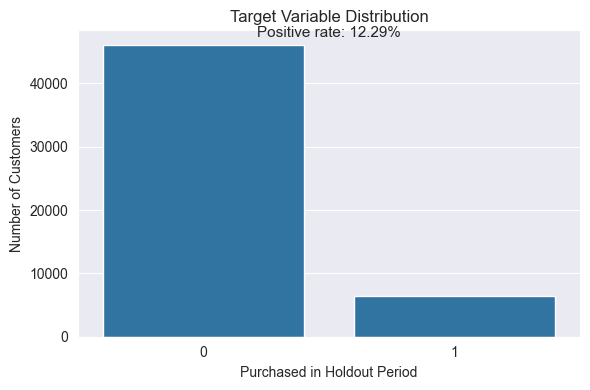

Positive class (purchased in holdout): 6,451 (12.3%)
Negative class (no holdout purchase):  46,056 (87.7%)


In [5]:
positive_rate = df['purchased_in_holdout'].mean()

plt.figure(figsize=(6,4))
sns.countplot(x='purchased_in_holdout', data=df)

plt.title("Target Variable Distribution")
plt.xlabel("Purchased in Holdout Period")
plt.ylabel("Number of Customers")

plt.text(
    0.5,
    df.shape[0]*0.9,
    f"Positive rate: {positive_rate:.2%}",
    ha="center",
    fontsize=11,
)

plt.tight_layout()
plt.show()

print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

**Observations**

Approximately 12% of customers make a purchase in the holdout period.
This imbalance suggests that evaluation metrics such as PR-AUC are more appropriate than accuracy. During model training, class imbalance was addressed using the `scale_pos_weight` parameter in XGBoost.

### 2.2 Customer Behavioral Patterns

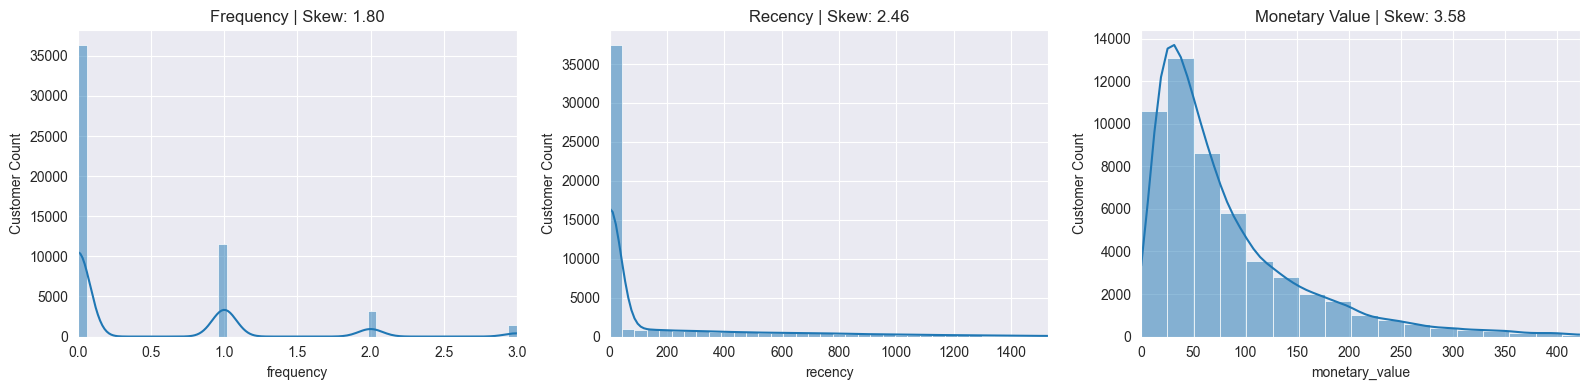

In [6]:
features = ['frequency', 'recency', 'monetary_value']

fig, axes = plt.subplots(1, len(features), figsize=(16, 4))

for i, feature in enumerate(features):
    sns.histplot(df[feature], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"{feature.replace('_', ' ').title()} | Skew: {df[feature].skew():.2f}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Customer Count")
    
    # clip extreme outliers for readability
    axes[i].set_xlim(0, df[feature].quantile(0.99))

plt.tight_layout()
plt.show()

**Observations**
- Most customers make very few repeat purchases.
- Recency is highly right-skewed, indicating many customers have not purchased recently.
- Monetary value is right-skewed, with most orders concentrated at lower values and a small number of high-value customers.

These patterns suggest that normalized behavioral features such as `purchase_rate` and recency-based ratios (e.g., `recency_ratio`) may be more informative than raw totals alone.

### 2.3 Engagement Behavior

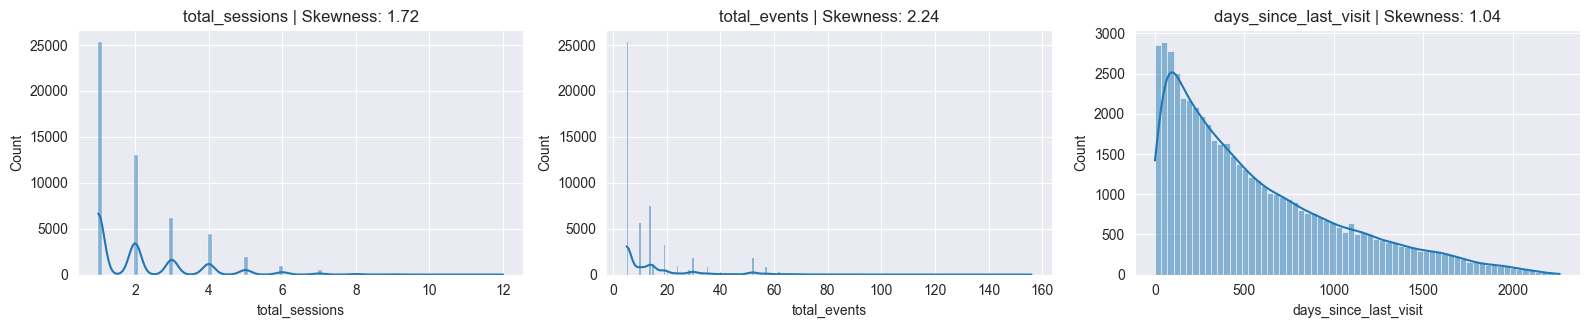

In [7]:
features = ['total_sessions', 'total_events', 'days_since_last_visit']

plt.figure(figsize=(16, len(features) * 3))
for idx, feature in enumerate(features, 1):
    plt.subplot(len(features), 3, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

**Observations**

- Engagement metrics such as `total_sessions` and `total_events` are heavily right-skewed, indicating that most customers interact with the platform only a few times.
- A long right tail is present in both distributions, suggesting a small segment of highly engaged users who generate disproportionately high activity.
- The distribution of `days_since_last_visit` shows that many customers have not interacted with the platform recently, indicating varying levels of customer engagement.
- These patterns highlight the importance of behavioral signals in predicting future purchases and motivate the use of normalized engagement features such as `sessions_per_day` and `events_per_day`.

### 2.4 Geographic Differences in Repeat Purchasing
To determine whether geographic differences influence repeat purchasing behavior, we analyzed repeat purchase metrics by country.

In [10]:
# 1. Does country have 
country_stats = (
    df.groupby("country")
      .agg(
          customers=("country", "count"),
          avg_frequency=("frequency", "mean"),
          avg_recency=("recency", "mean"),
          avg_order_value=("avg_order_value", "mean"),
          purchase_rate_target=("purchased_in_holdout", "mean")
      )
      .sort_values("customers", ascending=False)
)

country_stats

,customers,avg_frequency,avg_recency,avg_order_value,purchase_rate_target
country,,,,,
China,17843,0.422687,165.812980,86.243998,0.121056
United States,11627,0.417735,165.492130,86.197211,0.123334
Brasil,7807,0.427949,162.990137,85.044012,0.123351
South Korea,2816,0.445312,176.406605,86.473200,0.127486
France,2524,0.415610,164.843106,86.225254,0.118463
United Kingdom,2425,0.421856,164.366598,84.040125,0.124124
Germany,2203,0.408080,155.953246,88.847815,0.127553
Spain,2089,0.423169,162.469124,90.685401,0.126855
Japan,1243,0.435237,164.095736,87.868325,0.116653


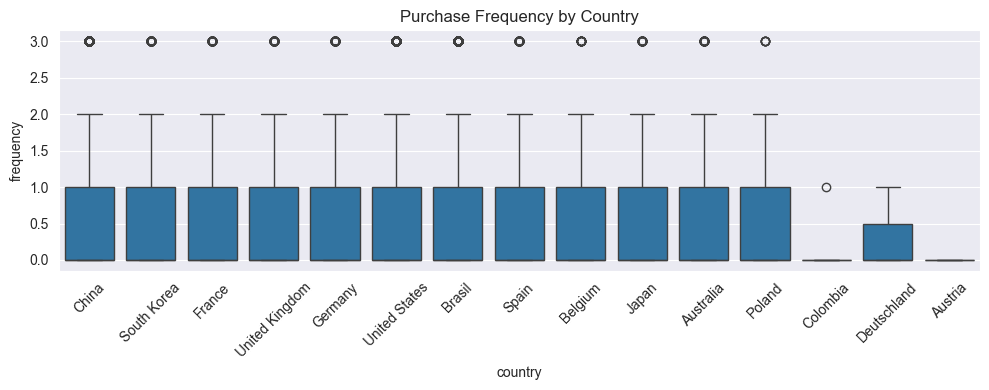

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="country", y="frequency")
plt.xticks(rotation=45)
plt.title("Purchase Frequency by Country")
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import f_oneway

groups = [g["frequency"].values for _, g in df.groupby("country")]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(0.49600000037024805), pvalue=np.float64(0.9368364424209052))

### 2.5 Feature Correlation

<Axes: >

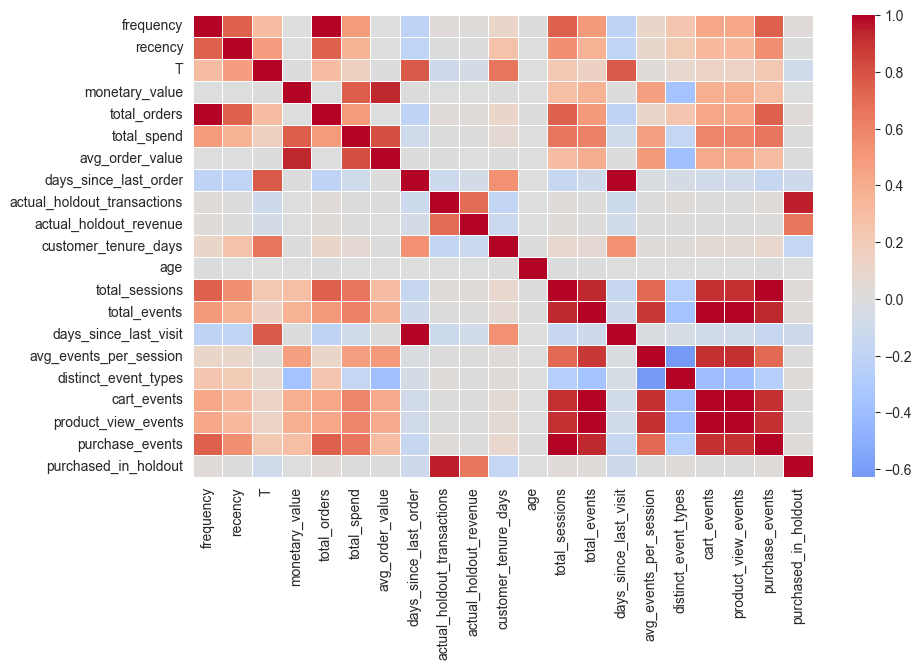

In [12]:
numeric_cols = df.select_dtypes(include='number').columns.drop('user_id')

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', linewidth=0.5,center=0)

**Observations**

- The correlation heatmap reveals several clusters of related features, including purchase history variables, engagement metrics, and recency signals.
- Purchase-related variables such as frequency, total_orders, and total_spend exhibit strong positive correlations, indicating they capture similar aspects of customer purchasing behavior.
- Similarly, engagement metrics such as total_sessions, total_events, and product_view_events are highly correlated, reflecting different measures of customer interaction intensity.
- Recency-based features also show strong relationships, suggesting that recent customer activity plays an important role in predicting future purchases.
- Because the final model uses a tree-based algorithm (XGBoost), these correlations are less problematic, as tree models can handle redundant features effectively.

### Key Insights

## 3. Feature Engineering

In [13]:
# Derived features 
# what fraction of lifetime included repeat activity
df['recency_ratio'] = df['recency'] / df['T']

# Purchase intensity
df["purchase_rate"] = df["frequency"] / df["T"]

# Recency relative to tenure
df["recency_tenure_ratio"] = df["days_since_last_order"] / df["customer_tenure_days"]

# Engagement intensity
df["events_per_day"] = df["total_events"] / df["customer_tenure_days"]
df["sessions_per_day"] = df["total_sessions"] / df["customer_tenure_days"]

# Shopping intent
df["cart_rate"] = df["cart_events"] / df["total_sessions"]
df["view_rate"] = df["product_view_events"] / df["total_sessions"]

NUMERIC_FEATURES = [
    # Purchase history (BG/NBD inputs)
    'frequency', 'recency', 'T', 'monetary_value',
    # Transaction context
    'total_orders', 'avg_order_value', 'days_since_last_order',
    # Demographics
    'customer_tenure_days', 'age',
    # Engagement
    'total_sessions', 'total_events', 'days_since_last_visit',
    'avg_events_per_session', 'cart_events', 'product_view_events',
    # Derived
    'recency_ratio', 'purchase_rate', 'recency_tenure_ratio', 
    'events_per_day', 'sessions_per_day',
    'cart_rate', 'view_rate'
]

CATEGORICAL_FEATURES = ['gender', 'traffic_source', 'country']

# Encode categorical features
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features: {len(FEATURE_COLS)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features: 25
Target distribution: {0: 46056, 1: 6451}


## 4. Train / Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} ({y_test.mean():.1%} positive)")

Train: 42,005 (12.3% positive)
Test:  10,502 (12.3% positive)


## 5. Train XGBoost Classifier

In [15]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0,
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
clf

scale_pos_weight = 7.14


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

## 6. Probability Calibration

`scale_pos_weight` distorts raw probabilities. Isotonic regression calibrates them to match the true positive rate.

**Note:**
- `scale_pos_weight` helps the model pay attention to rare positives by increasing the loss contribution of positive examples. This effectively makes the algorithm behave as if positives are more common than they actually are. As a result, the model optimizes a **weighted loss rather than the true data distribution**, which improves classification performance on imbalanced data but can produce **poorly calibrated (typically inflated) probability estimates**.
- If we only care about **ranking customers** (e.g., top 10% marketing targets), calibration isn't critical. However, if probabilities are used for revenue forecasting, expected conversion rates, or decision thresholds, calibration becomes important.

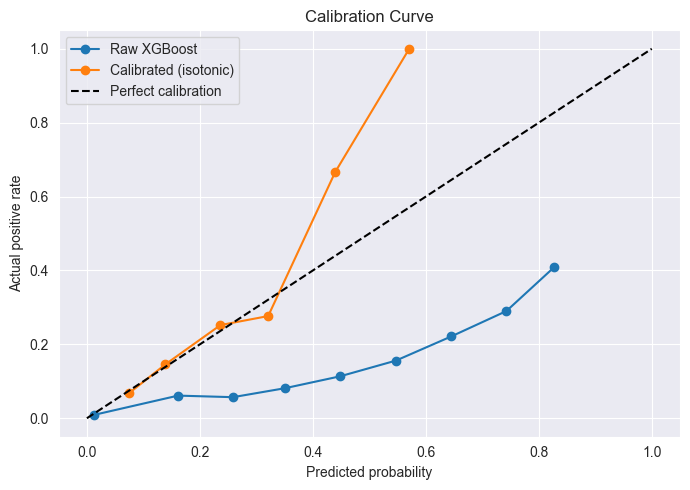

In [16]:
cal_clf = CalibratedClassifierCV(clf, method='isotonic', cv=5)  # isotonic regression learns monotonic function but doesn't assume a specific shape.
cal_clf.fit(X_train, y_train)

# Calibration curve on test set
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]
y_prob_raw = clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [('Raw XGBoost', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evaluation

In [17]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)
from sklearn.model_selection import cross_val_score

y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr = average_precision_score(y_test, y_prob)
roc = roc_auc_score(y_test, y_prob)
ll = log_loss(y_test, y_prob)

print(f"PR-AUC: {pr:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"LogLoss: {ll:.4f}")

scores = cross_val_score(cal_clf, X, y, cv=5, scoring="average_precision")
print(f"mean cross val score: {scores.mean():.4f}")
print(f"mean cross val std: {scores.std():.4f}")

PR-AUC: 0.2262
ROC-AUC: 0.6745
LogLoss: 0.3503
mean cross val score: 0.1841
mean cross val std: 0.0313


In [18]:
y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
baseline = y_test.mean()

print("=== Purchase Propensity Model ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")

=== Purchase Propensity Model ===
PR-AUC:   0.2262  (baseline: 0.1228, lift: 1.8x)
ROC-AUC:  0.6745


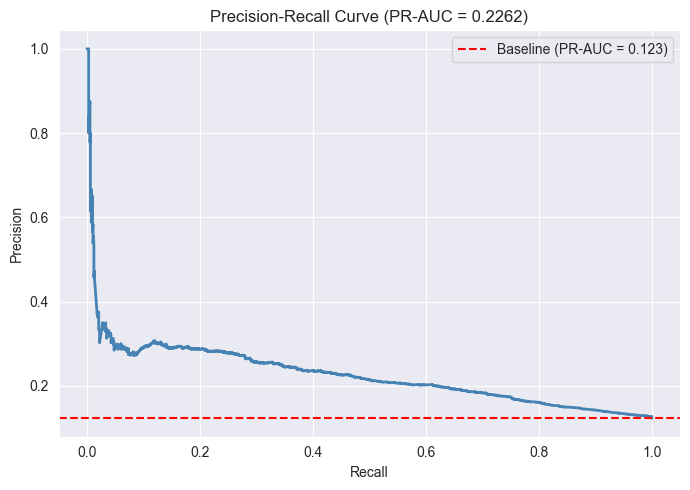

In [19]:
# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (PR-AUC = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers  = ('y_true', 'count'),
    actual_rate  = ('y_true', 'mean'),
    avg_prob     = ('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis ===")
print(decile_stats.to_string())
print(f"\nTop decile purchase rate: {decile_stats.iloc[-1]['actual_rate']:.1%}")
print(f"Bottom decile purchase rate: {decile_stats.iloc[0]['actual_rate']:.1%}")
print(f"Lift (top vs bottom): {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x")

=== Decile Analysis ===
        n_customers  actual_rate  avg_prob
decile                                    
1              1085       0.0479    0.0439
2              1170       0.0615    0.0733
3               896       0.0759    0.0799
4              1052       0.0751    0.0854
5              1048       0.0821    0.0944
6              1050       0.1057    0.1087
7              1050       0.1505    0.1283
8              1054       0.1603    0.1527
9              1046       0.1893    0.1940
10             1051       0.2826    0.2645

Top decile purchase rate: 28.3%
Bottom decile purchase rate: 4.8%
Lift (top vs bottom): 5.9x


## 8. Feature Importance

In [21]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    cal_clf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision"
)

perm_importance = pd.Series(
    r.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance)

customer_tenure_days      0.047916
sessions_per_day          0.029711
days_since_last_visit     0.019970
frequency                 0.011897
events_per_day            0.007494
T                         0.007056
avg_order_value           0.006448
days_since_last_order     0.006213
purchase_rate             0.005757
monetary_value            0.005382
recency_tenure_ratio      0.003997
recency                   0.002004
total_orders              0.001623
recency_ratio             0.001521
total_sessions            0.000374
total_events              0.000252
avg_events_per_session    0.000172
cart_events               0.000089
cart_rate                -0.000004
gender_enc               -0.000072
product_view_events      -0.000082
view_rate                -0.000460
traffic_source_enc       -0.000526
age                      -0.000834
country_enc              -0.001043
dtype: float64


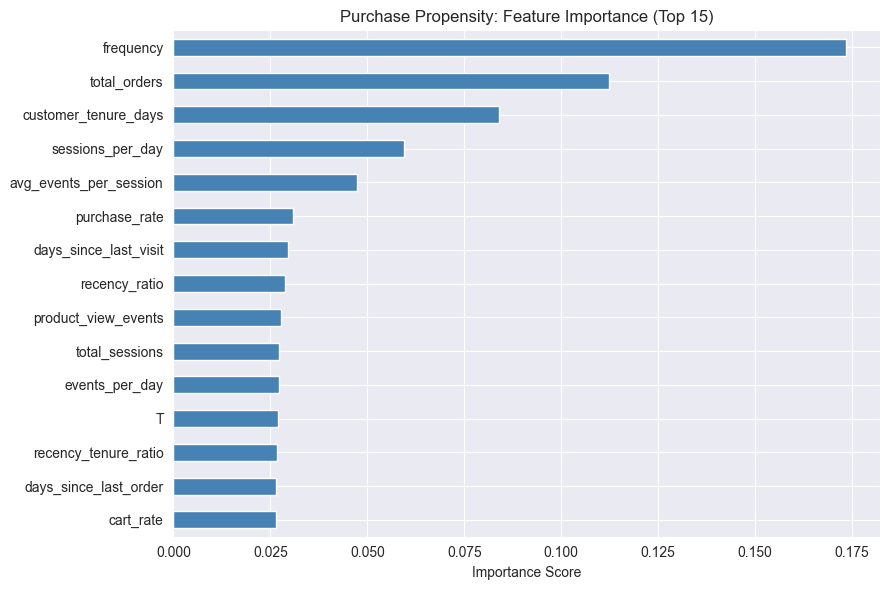

In [23]:
importance = pd.Series(clf.feature_importances_, index=FEATURE_COLS)
top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Purchase Propensity: Feature Importance (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Score All Customers and Save

In [24]:
# Score entire dataset
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print(f"p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    52507.0000
mean         0.1235
std          0.0671
min          0.0000
25%          0.0804
50%          0.1013
75%          0.1520
max          0.6987
Name: p_purchase, dtype: float64

Mean p_purchase: 0.1235 (base rate: 0.1229)


In [25]:
# Save model and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to data/processed/stage1_scored.csv
  Shape: 52,507 x 36


In [26]:
# Summary
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity")
print("=" * 50)
print(f"Customers scored:  {len(df):,}")
print(f"PR-AUC:            {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift over baseline)")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_clv_regression.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity
Customers scored:  52,507
PR-AUC:            0.2262 (1.8x lift over baseline)
ROC-AUC:           0.6745
Mean p_purchase:   0.1235

Next: 03_clv_regression.ipynb (Stage 2)
